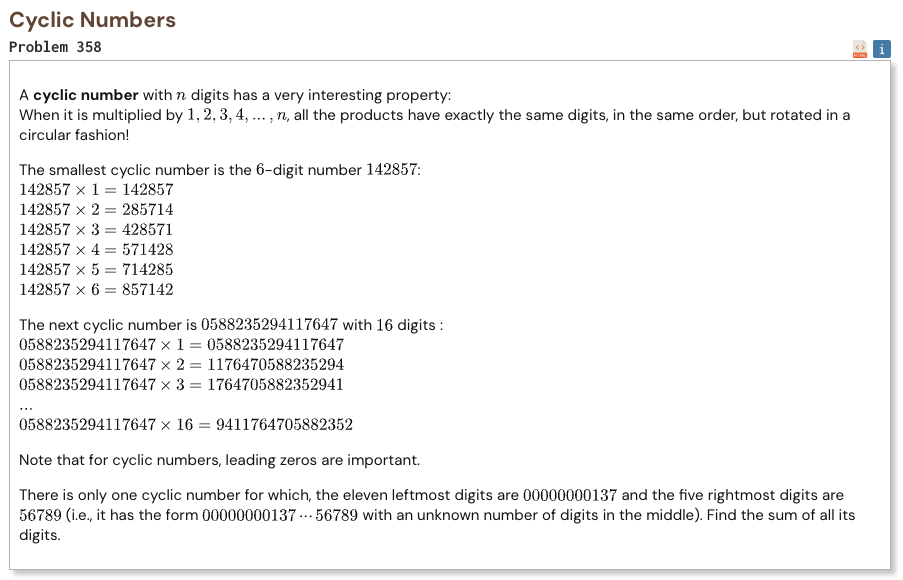

## Initial approach

* cyclic numbers come from the repeating decimal part of 1 / p
* the first digits restrict p to a small range
* the last digits give a modular condition on p
* only a few prime candidates remain
* test which candidate makes 10 a primitive root
* for a full cyclic number, the digit sum is half of 9 * period length
* the period length is p - 1

In [1]:
import math

def is_prime(n):
    if n < 2:
        return False

    if n % 2 == 0:
        return n == 2

    d = 3

    while d * d <= n:
        if n % d == 0:
            return False

        d += 2

    return True

def prime_factors(n):
    factors = []
    d = 2

    while d * d <= n:
        if n % d == 0:
            factors.append(d)

            while n % d == 0:
                n //= d

        d += 1 if d == 2 else 2

    if n > 1:
        factors.append(n)

    return factors

def is_full_reptend_prime(p):
    factors = prime_factors(p - 1)

    for q in factors:
        if pow(10, (p - 1) // q, p) == 1:
            return False

    return True

def solve():
    lower = math.ceil(1 / 0.00000000138)
    upper = math.floor(1 / 0.00000000137)

    suffix = 56789
    modulus = 100000

    residue = None

    for r in range(modulus):
        if (suffix * r + 1) % modulus == 0:
            residue = r
            break

    start = lower + ((residue - lower) % modulus)

    for p in range(start, upper + 1, modulus):
        if is_prime(p) and is_full_reptend_prime(p):
            return 9 * (p - 1) // 2

In [2]:
%%time
result = solve()
print("Result:", result)

Result: 3284144505
CPU times: user 4.91 ms, sys: 168 μs, total: 5.08 ms
Wall time: 5.12 ms
